In [ ]:
%cd ~/ASMSA/trpcage

In [1]:
threads = 2

import os
os.environ['OMP_NUM_THREADS']=str(threads)
import tensorflow as tf

# PyTorch favours OMP_NUM_THREADS in environment
import torch

# Tensorflow needs explicit cofig calls
tf.config.threading.set_inter_op_parallelism_threads(threads)
tf.config.threading.set_intra_op_parallelism_threads(threads)

2025-10-14 13:30:24.227283: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-14 13:30:24.248756: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-14 13:30:24.253340: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-14 13:30:24.266152: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-14 13:30:25.110467: W tensorflow/compiler/tf2

In [2]:
from tensorflow import keras as k
import numpy as np
import mdtraj as md
import matplotlib.pyplot as plt
import math
import datetime
from asmsa_callbacks import callbacks

2025-10-14 13:30:27.694102: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18226 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 2g.20gb, pci bus id: 0000:61:00.0, compute capability: 8.0


In [3]:
exec(open('inputs.py').read())

In [4]:
def _compute_number_of_neurons(layers, seed):
    neurons = [seed]

    tmp = seed
    for _ in range(layers-1):
        tmp = int(tmp / 2)
        neurons.append(tmp)
    return neurons

In [5]:
class AAEClassModel(k.models.Model):
    def __init__(self,
            n_features,
            n_classes,
            enc_layers, enc_seed,
            disc_layers, disc_seed,
            af='gelu',
            bn_momentum=0.8, leak_alpha=0.2,
            latent_dim=2,
            dist_threshold=5.,
            seed=42
        ):

        super().__init__()
        
        # Imposta il seed per la riproducibilità
        np.random.seed(seed)
        tf.random.set_seed(seed)
        
# https://doi.org/10.48550/arXiv.1511.05644, Sect. 7 / Fig. 10
        self.n_classes = n_classes
        self.latent_dim = latent_dim
        self.dist_threshold2 = dist_threshold*dist_threshold
        
        enc_neurons = _compute_number_of_neurons(enc_layers, enc_seed) 
        disc_neurons = _compute_number_of_neurons(disc_layers, disc_seed)

        inp = k.Input(shape=(n_features,),name='inp')
        out = inp

        for n in range(enc_layers):
            out = k.layers.Dense(enc_neurons[n],activation=af,name=f'enc_{n}')(out)
            out = k.layers.BatchNormalization(momentum=bn_momentum, name=f'enc_bn_{n}')(out)

        z = k.layers.Dense(latent_dim,name='latent_z')(out)
        y = k.layers.Dense(n_classes,activation='softmax',name='latent_y')(out)

        chs = k.layers.Dense(latent_dim,name='cluster_heads')
        hz = chs(y)
        d = (math.pow(n_classes,1./latent_dim) - 1) * dist_threshold / 2 / 3 # XXX
        chs.set_weights([
            np.random.uniform(low=-d,high=d,size=(n_classes,latent_dim)),
            np.random.normal(size=(latent_dim,))
        ])
        
        latent = k.layers.Add(name='add_z_hz')([z,hz])

        out = latent
        for n in reversed(range(enc_layers)):
            out = k.layers.Dense(enc_neurons[n],activation=af,name=f'dec_{n}')(out)
            out = k.layers.BatchNormalization(momentum=bn_momentum, name=f'dec_bn_{n}')(out)

        dec_out = k.layers.Dense(n_features,name='dec_out')(out)

        out = y
        for n in range(disc_layers):
            out = k.layers.Dense(disc_neurons[n],name=f'y_disc_{n}')(out)
            out = k.layers.LeakyReLU(negative_slope=leak_alpha,name=f'y_disc_relu_{n}')(out)
        
        y_disc_out = k.layers.Dense(1,name='y_disc_out')(out)

        out = z
        for n in range(disc_layers):
            out = k.layers.Dense(disc_neurons[n],name=f'z_disc_{n}')(out)
            out = k.layers.LeakyReLU(negative_slope=leak_alpha,name=f'z_disc_relu_{n}')(out)

        z_disc_out = k.layers.Dense(1,name='z_disc_out')(out)

        self.enc = k.Model(inputs=inp,outputs=[y,z])
        self.sum = k.Model(inputs=[y,z],outputs=latent)
        self.sumenc = k.Model(inputs=inp,outputs=latent)
        self.dec = k.Model(inputs=latent,outputs=dec_out)
        self.heads = k.Model(inputs=y,outputs=hz)
        # self.ae = k.Model(inputs=inp,outputs=dec_out)
        self.y_disc = k.Model(inputs=y,outputs=y_disc_out)
        self.z_disc = k.Model(inputs=z,outputs=z_disc_out)

    def compile(self,optimizer=None,lr=None):
        
        if optimizer is None:
            optimizer = tf.keras.optimizers.AdamW(
            learning_rate=1e-4,
            weight_decay=1e-5,
            beta_1=0.9,
            beta_2=0.999
        )
            opt = optimizer
            
        else:
            opt = optimizer

        self.ae_loss = k.losses.Huber() #MeanSquaredError()

        super().compile(optimizer=opt,loss=self.ae_loss)
        self.optimizer.build(self.enc.trainable_weights+self.sum.trainable_weights+self.dec.trainable_weights+self.y_disc.trainable_weights+self.z_disc.trainable_weights)

        self.enc.compile()
        self.dec.compile()
        self.y_disc.compile()
        self.z_disc.compile()

    @tf.function
    def train_step(self,in_batch):
        if isinstance(in_batch, tuple):
            batch = in_batch[0]
        else:
            batch = in_batch

        # autoencoder
        with tf.GradientTape() as aet:
            y,z = self.enc(batch)
            rec = self.dec(self.sum([y,z]))
            ael = self.ae_loss(batch,rec)
    
        aew = self.enc.trainable_weights + self.sum.trainable_weights + self.dec.trainable_weights
        aeg = aet.gradient(ael,aew)
        self.optimizer.apply_gradients(zip(aeg,aew))
    
        # categoric discriminator
        idx = tf.random.uniform((batch.shape[0],), minval=0, maxval=self.n_classes, dtype=tf.int32)
        randy = tf.one_hot(idx, depth=self.n_classes)
    
        # binary crossentropy from logits
        with tf.GradientTape() as yt:
            nyp = self.y_disc(y)
            nyp *= tf.random.uniform(tf.shape(nyp), 1., 1.05)
            nyl = tf.reduce_mean(nyp,axis=0)
    
            pyp = self.y_disc(randy)
            pyp *= tf.random.uniform(tf.shape(pyp), 1., 1.05)
            pyl = -tf.reduce_mean(pyp,axis=0)
            y_disc_loss = (nyl + pyl) * 1e-5 #XXX
    
        yg = yt.gradient(y_disc_loss,self.y_disc.trainable_weights)
        self.optimizer.apply_gradients(zip(yg,self.y_disc.trainable_weights))
    
        # cheet it
        with tf.GradientTape() as yct:
            yc = self.y_disc(self.enc(batch)[0])
            yc *= tf.random.uniform(tf.shape(yc), 1., 1.05)
            ycl = -tf.reduce_mean(yc, axis=0) * 1e-5 #XXX
    
        ycg = yct.gradient(ycl,self.enc.trainable_weights)
        self.optimizer.apply_gradients(zip(ycg,self.enc.trainable_weights))
            
        # intra category discriminator
        randz = tf.random.normal(shape=(batch.shape[0], self.latent_dim))
    
        with tf.GradientTape() as zt:
            nzp = self.z_disc(z)
            nzp *= tf.random.uniform(tf.shape(nzp), 1., 1.05)
            nzl = tf.reduce_mean(nzp,axis=0)
    
            pzp = self.z_disc(randz)
            pzp *= tf.random.uniform(tf.shape(pzp), 1., 1.05)
            pzl = -tf.reduce_mean(pzp,axis=0)
            z_disc_loss = nzl + pzl
    
        zg = zt.gradient(z_disc_loss,self.z_disc.trainable_weights)
        self.optimizer.apply_gradients(zip(zg,self.z_disc.trainable_weights))
            
        # cheet it
        with tf.GradientTape() as zct:
            zc = self.z_disc(self.enc(batch)[1])
            zc *= tf.random.uniform(tf.shape(zc), 1., 1.05)
            zcl = -tf.reduce_mean(zc, axis=0)
    
        zcg = zct.gradient(zcl,self.enc.trainable_weights)
        self.optimizer.apply_gradients(zip(zcg,self.enc.trainable_weights))
        
        # keep cluster heads apart
        randc = tf.linalg.diag(tf.random.uniform((self.n_classes,),0.95,1.05))
        with tf.GradientTape() as ht:
            ch = self.heads(randc)
            norms = tf.reduce_sum(tf.square(ch), axis=1, keepdims=True)  # shape=(N,1)
            dists_squared = norms - 2 * tf.matmul(ch, ch, transpose_b=True) + tf.transpose(norms)
            small_dists = tf.boolean_mask(tf.exp(-dists_squared), dists_squared < self.dist_threshold2)
            hl = tf.reduce_sum(small_dists)/self.dist_threshold2/self.n_classes/self.n_classes * 21. #XXX

        hg = ht.gradient(hl,self.heads.trainable_weights)
        self.optimizer.apply_gradients(zip(hg,self.heads.trainable_weights))

        return {
            'ae_loss' : ael,
            'y_disc_loss': y_disc_loss,
            'z_disc_loss': z_disc_loss,
            'y_cheat_loss': ycl,
            'z_cheat_loss': zcl,
            'cluster_head_loss': hl
        }

    @tf.function
    def test_step(self, in_batch):
        """Test step per il monitoraggio della validazione durante il training"""
        if isinstance(in_batch, tuple):
            batch = in_batch[0]
        else:
            batch = in_batch

        y, z = self.enc(batch, training=False)
        rec = self.dec(self.sum([y, z]), training=False)
        val_ae_loss = self.ae_loss(batch, rec)
        
        idx = tf.random.uniform((batch.shape[0],), minval=0, maxval=self.n_classes, dtype=tf.int32)
        randy = tf.one_hot(idx, depth=self.n_classes)
        
        nyp = self.y_disc(y, training=False)
        nyl = tf.reduce_mean(nyp, axis=0)
        pyp = self.y_disc(randy, training=False)
        pyl = -tf.reduce_mean(pyp, axis=0)
        val_y_disc_loss = (nyl + pyl) * 1e-5
        
        yc = self.y_disc(y, training=False)
        val_y_cheat_loss = -tf.reduce_mean(yc, axis=0) * 1e-5
        
        randz = tf.random.normal(shape=(batch.shape[0], self.latent_dim))
        nzp = self.z_disc(z, training=False)
        nzl = tf.reduce_mean(nzp, axis=0)
        pzp = self.z_disc(randz, training=False)
        pzl = -tf.reduce_mean(pzp, axis=0)
        val_z_disc_loss = nzl + pzl
        
        # Z cheat validation loss
        zc = self.z_disc(z, training=False)
        val_z_cheat_loss = -tf.reduce_mean(zc, axis=0)
        
        # Cluster head validation loss
        randc = tf.linalg.diag(tf.ones((self.n_classes,)))  # No random noise for validation
        ch = self.heads(randc, training=False)
        norms = tf.reduce_sum(tf.square(ch), axis=1, keepdims=True)
        dists_squared = norms - 2 * tf.matmul(ch, ch, transpose_b=True) + tf.transpose(norms)
        small_dists = tf.boolean_mask(tf.exp(-dists_squared), dists_squared < self.dist_threshold2)
        val_cluster_head_loss = tf.reduce_sum(small_dists)/self.dist_threshold2/self.n_classes/self.n_classes * 21.

        return {'ae_loss': val_ae_loss,}

    @tf.function
    def call(self,inp):
        return self.sum(self.enc(inp))

    def call_enc(self,inp):
        return self.call(inp)
            

In [6]:
# XXX: essential hps manually
batch_size = 64
best_enc_seed=128
best_disc_seed=128 
ae_layers=2 
disc_layers=2
#learning_rate=0.00002
#n_classes = 40

## weaken discriminators
#best_disc_seed=64
#disc_layers=2
#learning_rate=0.00002
n_classes = 4

# weird experiments
# best_disc_seed=32

In [7]:
X_train = tf.data.Dataset.load('01.datasets/intcoords/train')

# get batched version of dataset to feed to AAE model for training
X_train_batched = X_train.batch(batch_size,drop_remainder=True)

# get numpy version for visualization purposes
X_train_np = np.stack(list(X_train))
X_train_np.shape

2025-10-14 13:30:31.964345: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(34525, 911)

In [8]:
X_test = tf.data.Dataset.load('01.datasets/intcoords/test')

# get numpy version for visualization purposes
X_test_np = np.stack(list(X_test))
X_test_np.shape

2025-10-14 13:30:33.081411: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(7419, 911)

In [9]:
X_val = tf.data.Dataset.load('01.datasets/intcoords/validate').batch(batch_size,drop_remainder=True)
X_val_np = np.stack(list(X_val))
X_val_np.shape

(117, 64, 911)

In [10]:
m = AAEClassModel(n_features=X_train_np.shape[1],n_classes=n_classes,enc_layers=ae_layers,enc_seed=best_enc_seed,disc_layers=disc_layers,disc_seed=best_disc_seed)

In [11]:
log_dir = "logs/class_traom/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

cb = callbacks(log_dir, m, X_test_np,freq=20, monitor="val_ae_loss")

In [12]:
m.compile()#lr=learning_rate)

In [13]:
m.summary()

Model: "aae_class_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional (Functional)         │ [(None, 10), (None,    │       126,540 │
│                                 │ 2)]                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 2)              │            22 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_2 (Functional)       │ (None, 2)              │       126,562 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_3 (Functional)       │ (None, 911)            │       126,799 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_4 (Functional)       │ (None, 2)              │            22 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_5 (Functional)       │ (None, 1)              │           897 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_6 (Functional)       │ (None, 1)              │           641 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 763,163 (2.91 MB)

 Trainable params: 254,131 (992.70 KB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 508,264 (1.94 MB)

Epoch 1/500


/opt/conda/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:678: UserWarning: Gradients do not exist for variables ['kernel', 'bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
I0000 00:00:1760448641.310174  314764 service.cc:146] XLA service 0x757b14004b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760448641.310222  314764 service.cc:154]   StreamExecutor device (0): NVIDIA A100 80GB PCIe MIG 2g.20gb, Compute Capability 8.0
2025-10-14 13:30:41.413376: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:61] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. StatefulPartitionedCall/random_uniform_1/RandomUniform
2025-10-14 13:30:41.455055: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:107] Warning: Using tf.random.uniform with 

539/539 - 12s - 23ms/step - ae_loss: 0.3612 - cluster_head_loss: 0.1803 - y_cheat_loss: 5.4650e-07 - y_disc_loss: -3.8831e-06 - z_cheat_loss: 0.0445 - z_disc_loss: 0.0915 - val_ae_loss: 0.3553 - learning_rate: 1.0000e-04
Epoch 2/500
539/539 - 2s - 4ms/step - ae_loss: 0.3253 - cluster_head_loss: 0.1676 - y_cheat_loss: 2.6666e-07 - y_disc_loss: -1.3765e-05 - z_cheat_loss: -6.9407e-04 - z_disc_loss: 0.0870 - val_ae_loss: 0.3331 - learning_rate: 1.0000e-04
Epoch 3/500
539/539 - 2s - 4ms/step - ae_loss: 0.3185 - cluster_head_loss: 0.1494 - y_cheat_loss: -1.1190e-07 - y_disc_loss: -4.7703e-05 - z_cheat_loss: -2.3802e-02 - z_disc_loss: 0.0445 - val_ae_loss: 0.3288 - learning_rate: 1.0000e-04
Epoch 4/500
539/539 - 2s - 5ms/step - ae_loss: 0.3154 - cluster_head_loss: 0.1362 - y_cheat_loss: -3.5219e-06 - y_disc_loss: -9.3631e-05 - z_cheat_loss: -2.8915e-02 - z_disc_loss: 0.0127 - val_ae_loss: 0.3260 - learning_rate: 1.0000e-04
Epoch 5/500
539/539 - 3s - 5ms/step - ae_loss: 0.2958 - cluster_head_

/opt/conda/lib/python3.10/site-packages/asmsa/visualizer.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[0][0].scatter(x, y, s=0.1, cmap=self.cmap)


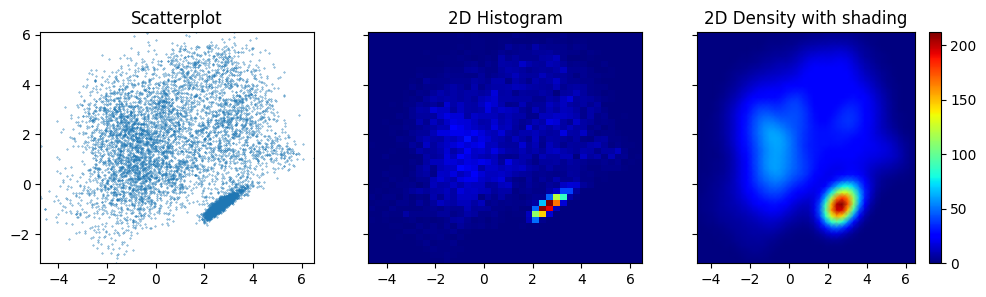

539/539 - 3s - 6ms/step - ae_loss: 0.2621 - cluster_head_loss: 0.0861 - y_cheat_loss: -1.3007e-03 - y_disc_loss: -8.7143e-04 - z_cheat_loss: -4.7230e-02 - z_disc_loss: 3.5811e-05 - val_ae_loss: 0.2762 - learning_rate: 1.0000e-04
Epoch 21/500
539/539 - 3s - 5ms/step - ae_loss: 0.2641 - cluster_head_loss: 0.0857 - y_cheat_loss: -2.3200e-03 - y_disc_loss: -1.4963e-05 - z_cheat_loss: -5.0980e-02 - z_disc_loss: 0.0051 - val_ae_loss: 0.2759 - learning_rate: 1.0000e-04
Epoch 22/500
539/539 - 2s - 5ms/step - ae_loss: 0.2614 - cluster_head_loss: 0.0855 - y_cheat_loss: -1.5600e-03 - y_disc_loss: -7.5387e-04 - z_cheat_loss: -4.9685e-02 - z_disc_loss: 0.0028 - val_ae_loss: 0.2756 - learning_rate: 1.0000e-04
Epoch 23/500
539/539 - 3s - 5ms/step - ae_loss: 0.2610 - cluster_head_loss: 0.0852 - y_cheat_loss: -1.2484e-03 - y_disc_loss: -4.5593e-04 - z_cheat_loss: -5.1763e-02 - z_disc_loss: 0.0022 - val_ae_loss: 0.2736 - learning_rate: 1.0000e-04
Epoch 24/500
539/539 - 3s - 5ms/step - ae_loss: 0.2591 - 

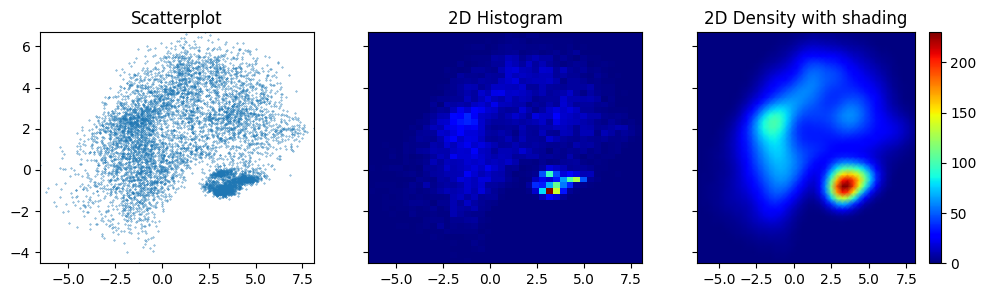

539/539 - 3s - 6ms/step - ae_loss: 0.2525 - cluster_head_loss: 0.0841 - y_cheat_loss: -5.8745e-04 - y_disc_loss: -9.3195e-04 - z_cheat_loss: -2.6878e-02 - z_disc_loss: -1.4339e-03 - val_ae_loss: 0.2639 - learning_rate: 1.0000e-04
Epoch 41/500
539/539 - 3s - 5ms/step - ae_loss: 0.2516 - cluster_head_loss: 0.0841 - y_cheat_loss: -3.9575e-04 - y_disc_loss: -1.6029e-03 - z_cheat_loss: -2.6847e-02 - z_disc_loss: 5.7675e-04 - val_ae_loss: 0.2626 - learning_rate: 1.0000e-04
Epoch 42/500
539/539 - 3s - 5ms/step - ae_loss: 0.2514 - cluster_head_loss: 0.0842 - y_cheat_loss: -3.8284e-04 - y_disc_loss: -1.6577e-03 - z_cheat_loss: -2.9436e-02 - z_disc_loss: 9.3354e-04 - val_ae_loss: 0.2626 - learning_rate: 1.0000e-04
Epoch 43/500
539/539 - 3s - 5ms/step - ae_loss: 0.2517 - cluster_head_loss: 0.0841 - y_cheat_loss: -7.1072e-04 - y_disc_loss: -1.4917e-03 - z_cheat_loss: -2.6891e-02 - z_disc_loss: -2.3645e-03 - val_ae_loss: 0.2621 - learning_rate: 1.0000e-04
Epoch 44/500
539/539 - 3s - 5ms/step - ae_l

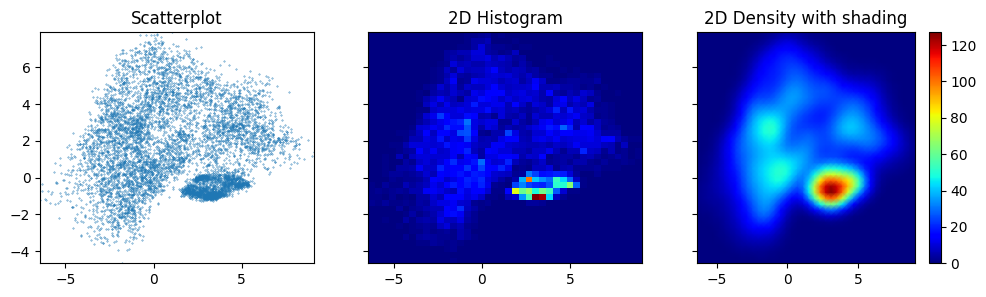

539/539 - 3s - 6ms/step - ae_loss: 0.2482 - cluster_head_loss: 0.0840 - y_cheat_loss: -2.5900e-03 - y_disc_loss: -5.2567e-03 - z_cheat_loss: -2.4333e-02 - z_disc_loss: -1.2963e-04 - val_ae_loss: 0.2578 - learning_rate: 1.0000e-04
Epoch 61/500
539/539 - 3s - 5ms/step - ae_loss: 0.2479 - cluster_head_loss: 0.0840 - y_cheat_loss: -2.8335e-03 - y_disc_loss: -7.8676e-03 - z_cheat_loss: -2.2518e-02 - z_disc_loss: 4.4060e-04 - val_ae_loss: 0.2575 - learning_rate: 1.0000e-04
Epoch 62/500
539/539 - 3s - 5ms/step - ae_loss: 0.2485 - cluster_head_loss: 0.0840 - y_cheat_loss: -3.0057e-03 - y_disc_loss: -7.3395e-03 - z_cheat_loss: -1.6406e-02 - z_disc_loss: -5.3782e-05 - val_ae_loss: 0.2574 - learning_rate: 1.0000e-04
Epoch 63/500
539/539 - 2s - 5ms/step - ae_loss: 0.2506 - cluster_head_loss: 0.0840 - y_cheat_loss: -4.7868e-03 - y_disc_loss: -5.8816e-03 - z_cheat_loss: -2.0983e-02 - z_disc_loss: 0.0054 - val_ae_loss: 0.2585 - learning_rate: 1.0000e-04
Epoch 64/500
539/539 - 3s - 5ms/step - ae_loss:

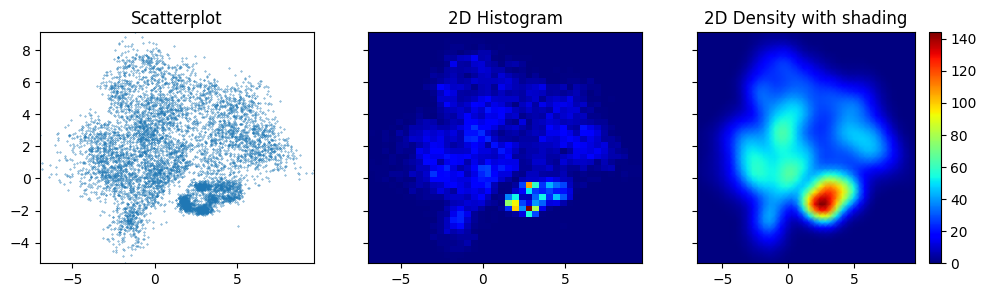

539/539 - 3s - 6ms/step - ae_loss: 0.2455 - cluster_head_loss: 0.0840 - y_cheat_loss: -8.0067e-03 - y_disc_loss: -1.6053e-02 - z_cheat_loss: -2.1561e-02 - z_disc_loss: 5.1799e-04 - val_ae_loss: 0.2551 - learning_rate: 1.0000e-04
Epoch 81/500
539/539 - 3s - 5ms/step - ae_loss: 0.2458 - cluster_head_loss: 0.0840 - y_cheat_loss: -7.8776e-03 - y_disc_loss: -1.5797e-02 - z_cheat_loss: -2.1241e-02 - z_disc_loss: 9.4067e-04 - val_ae_loss: 0.2542 - learning_rate: 1.0000e-04
Epoch 82/500
539/539 - 3s - 5ms/step - ae_loss: 0.2466 - cluster_head_loss: 0.0840 - y_cheat_loss: -3.4201e-02 - y_disc_loss: 0.0097 - z_cheat_loss: -2.0791e-02 - z_disc_loss: 0.0018 - val_ae_loss: 0.2566 - learning_rate: 1.0000e-04
Epoch 83/500
539/539 - 3s - 5ms/step - ae_loss: 0.2460 - cluster_head_loss: 0.0840 - y_cheat_loss: -3.3205e-02 - y_disc_loss: 0.0088 - z_cheat_loss: -2.4838e-02 - z_disc_loss: 0.0013 - val_ae_loss: 0.2569 - learning_rate: 1.0000e-04
Epoch 84/500
539/539 - 3s - 5ms/step - ae_loss: 0.2455 - cluste

In [14]:
m.fit(X_train_batched,epochs=500,verbose=2, validation_data=X_val,
     callbacks = cb)

In [ ]:
import asmsa.visualizer as visualizer

visualizer.Visualizer(figsize=(12,3)).make_visualization(m(X_train_np[::10,:]).numpy())

In [ ]:
visualizer.Visualizer(figsize=(12,3)).make_visualization(m(X_test_np).numpy())

In [ ]:
import tf2onnx
import onnx2torch
import tempfile

def _convert_to_onnx(model, destination_path):
    input_tensor = model.layers[0]._input_tensor
    input_signature = tf.TensorSpec(
        name=input_tensor.name, shape=input_tensor.shape, dtype=input_tensor.dtype
    )
    output_name = model.layers[-1].name

    @tf.function(input_signature=[input_signature])
    def _wrapped_model(input_data):
        return {output_name: model(input_data)}

    tf2onnx.convert.from_function(
        _wrapped_model, input_signature=[input_signature], output_path=destination_path
    )

In [ ]:
with tempfile.NamedTemporaryFile() as onnx:
    _convert_to_onnx(m.sumenc,onnx.name)
    torch_enc = onnx2torch.convert(onnx.name)

example_input = torch.randn([X_train_np.shape[1]])
traced_script_module = torch.jit.trace(torch_enc, example_input)

traced_script_module.save('encoder.pt')

In [ ]:
lenc = torch.jit.load('encoder.pt')
example_input = np.random.rand(10000,X_train_np.shape[1])
rtf = m.sumenc(example_input)
rpt = lenc(torch.tensor(example_input,dtype=torch.float32))

In [ ]:
maxerr = np.max(np.abs(rtf - rpt.detach().numpy()))
maxerr

In [ ]:
lowsk = m.sumenc(X_test_np)
lowsp = lenc(torch.tensor(X_test_np,dtype=torch.float32))
lowsk.shape, lowsp.shape

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(lowsk[:,0],lowsk[:,1])
plt.subplot(122)
plt.scatter(lowsp[:,0],lowsp[:,1])
plt.show()

In [ ]:
with tempfile.NamedTemporaryFile() as onnx:
    _convert_to_onnx(model.dec,onnx.name)
    torch_dec = onnx2torch.convert(onnx.name)

example_input = torch.randn([2])
traced_script_module = torch.jit.trace(torch_dec, example_input)

traced_script_module.save('decoder-unif.pt')

In [ ]:
ldec = torch.jit.load('decoder-unif.pt')
example_input = np.random.rand(10000,2)
rtf = model.dec(example_input)
rpt = ldec(torch.tensor(example_input,dtype=torch.float32))

In [ ]:
err = np.abs(rtf - rpt.detach().numpy())
train_mean = np.loadtxt('datasets/intcoords/mean.txt',dtype=np.float32).reshape(1,1,-1)
rerr = err/np.abs(train_mean)
np.max(err),np.max(rerr)

In [ ]:
tr = md.load('../DE-Shaw/trpcage_red.xtc',top=conf)

In [ ]:
# load all dataset
X_all = tf.data.Dataset.load('datasets/intcoords/X_all')

# get batched version of dataset to feed to AAE model for prediction
X_all_batched = X_all.batch(batch_size,drop_remainder=True)

# get numpy version for testing purposes
X_all_np = np.stack(list(X_all))
X_all_np.shape

In [ ]:
tica = np.load("tica.npy")

In [ ]:
lows = m(X_all_np).numpy()
rg = md.compute_rg(tr)
base = md.load(conf)
rmsd = md.rmsd(tr,base[0])
cmap = plt.get_cmap('rainbow')
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rg,cmap=cmap,s=1) #tica[:,0]
plt.colorbar(cmap=cmap)
plt.title("Rg")
plt.subplot(122)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rmsd,cmap=cmap,s=1) #tica[:,1]
plt.colorbar(cmap=cmap)
plt.title("RMSD")
plt.show()

In [ ]:
lows = m(X_all_np).numpy()
rg = md.compute_rg(tr)
base = md.load(conf)
rmsd = md.rmsd(tr,base[0])
cmap = plt.get_cmap('Dark2')
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rg,cmap=cmap,s=1) #tica[:,0]
plt.colorbar(cmap=cmap)
plt.title("Rg")
plt.subplot(122)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rmsd,cmap=cmap,s=1) #tica[:,1]
plt.colorbar(cmap=cmap)
plt.title("RMSD")
plt.show()

In [ ]:
traj = md.load_xtc("../DE-Shaw/trpcage_red.xtc", top=conf)

dssp = md.compute_dssp(traj, simplified=True)  # simplified=True → 'H' (alpha helix), 'E' (beta sheet), etc.

alpha_content_per_frame = np.mean(dssp == 'H', axis=1)

average_alpha_helix_content = np.mean(alpha_content_per_frame)

In [ ]:
lows = m(X_all_np).numpy()
rg = md.compute_rg(tr)
base = md.load(conf)
rmsd = md.rmsd(tr,base[0])
cmap = plt.get_cmap('rainbow')
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=alpha_content_per_frame,cmap=cmap,s=1) #tica[:,0]
plt.colorbar(cmap=cmap)
plt.title("alpha_content")

In [ ]:
lows = m(X_all_np).numpy()
rg = md.compute_rg(tr)
base = md.load(conf)
rmsd = md.rmsd(tr,base[0])
cmap = plt.get_cmap('rainbow')
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=tica[:,0],cmap=cmap,s=1) #
plt.colorbar(cmap=cmap)
plt.title("tica1")
plt.subplot(122)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=tica[:,1],cmap=cmap,s=1) #
plt.colorbar(cmap=cmap)
plt.title("tica2")
plt.show()

In [ ]:
heads = m.heads(tf.linalg.diag(tf.constant([1.] * n_classes))).numpy()
c = np.log(1e-8+np.sum(np.abs(m.enc(X_test_np)[0].numpy()),axis=0))
plt.scatter(heads[:,0],heads[:,1],c=c,cmap='magma')
plt.colorbar()
plt.show()

In [ ]:
z = m.enc(X_all_np)[1].numpy()
plt.scatter(z[:,0],z[:,1])
plt.show()

In [ ]:
y=m.enc(X_test_np)[0].numpy()[::100]
y.shape

In [ ]:
np.max(y,axis=1)

In [ ]:
y[0]

## Restored original visualizaition 

No "All" trajectories, no tica.npy ...

In [ ]:
tr = md.load('x_test.xtc',top=conf)

In [ ]:
lows = m(X_test_np).numpy()
rg = md.compute_rg(tr)
base = md.load(conf)
rmsd = md.rmsd(tr,base[0])
cmap = plt.get_cmap('rainbow')
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rg,cmap=cmap,s=1)
plt.colorbar(cmap=cmap)
plt.title("Rg")
plt.subplot(122)
plt.scatter(lows[:,0],lows[:,1],marker='.',c=rmsd,cmap=cmap,s=1)
plt.colorbar(cmap=cmap)
plt.title("RMSD")
plt.show()

In [ ]:
heads = m.heads(tf.linalg.diag(tf.constant([1.] * n_classes))).numpy()
y = m.enc(X_test_np)[0].numpy()
cl_size = np.sum(np.abs(y),axis=0)
c = np.log(1e-8+cl_size)
plt.scatter(heads[:,0],heads[:,1],c=c,cmap='magma')
plt.colorbar()
plt.show()

In [ ]:
cl_size, np.sum(cl_size), X_test_np.shape[0]

In [ ]:
z = m.enc(X_test_np)[1].numpy()
plt.scatter(z[:,0],z[:,1])
plt.show()

In [ ]:
heads

In [ ]:
def clust_stats(val,y):
    # "sizes" of clusters: sum of probabilities a test set point belongs to the category
    cl_size = np.sum(np.abs(y),axis=0)

    # mean value of each cluster: weight the values by the probabilities of belonging to the cluster, sum over clusters, and normalize with cluster "sizes"
    mean = (val @ y) / cl_size

    # variance of each cluster: squared difference from the mean, weighted by the probability, normalized
    var = np.sum(np.square((val.reshape((-1,1))-mean)) * y, axis=0) / cl_size

    return mean,var

In [ ]:
mean,s2=clust_stats(rmsd,y)
std = np.sqrt(s2)/mean
std, np.mean(std)

In [ ]:
mean,s2 = clust_stats(rg,y)
std = np.sqrt(s2)/mean
std, np.mean(std)

with best_disc_seed=32

rmsd:
(array([0.14352965, 0.20439424, 0.20825054, 0.33096504], dtype=float32), 0.22178486)

rg:
(array([0.08874252, 0.17166458, 0.18333455, 0.08933956]), 0.133270302660158)


In [ ]:
len(m.get_weights())

In [ ]:
len(m.enc.get_weights()),len(m.dec.get_weights()),len(m.sum.get_weights()),len(m.y_disc.get_weights()),len(m.z_disc.get_weights())

In [ ]:
m.summary()